In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

x = np.load('/content/drive/MyDrive/.npy_files/NEW_ROI_X.npy')
y = np.load('/content/drive/MyDrive/.npy_files/NEW_ROI_Y.npy')

print(x.shape)
print(y.shape)
print(x.dtype)
print(y.dtype)

(3242, 128, 128, 1)
(3242, 128, 128, 1)
float32
uint8


In [ ]:
!pip install -q torch torchvision
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q tqdm

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
x = np.load('/content/drive/MyDrive/.npy_files/NEW_ROI_X.npy')
y = np.load('/content/drive/MyDrive/.npy_files/NEW_ROI_Y.npy')

print("Images :", x.shape)
print("Masks  :", y.shape)

Images : (3242, 128, 128, 1)
Masks  : (3242, 128, 128, 1)


In [ ]:
print("Image Min :", x.min())
print("Image Max :", x.max())

print("Mask Values :", np.unique(y))

Image Min : 0.003921569
Image Max : 1.0000001
Mask Values : [0 1]


In [ ]:
x = x.astype(np.float32)

In [ ]:
y = y.astype(np.float32)

if y.max() > 1:
    y = y / 255.0

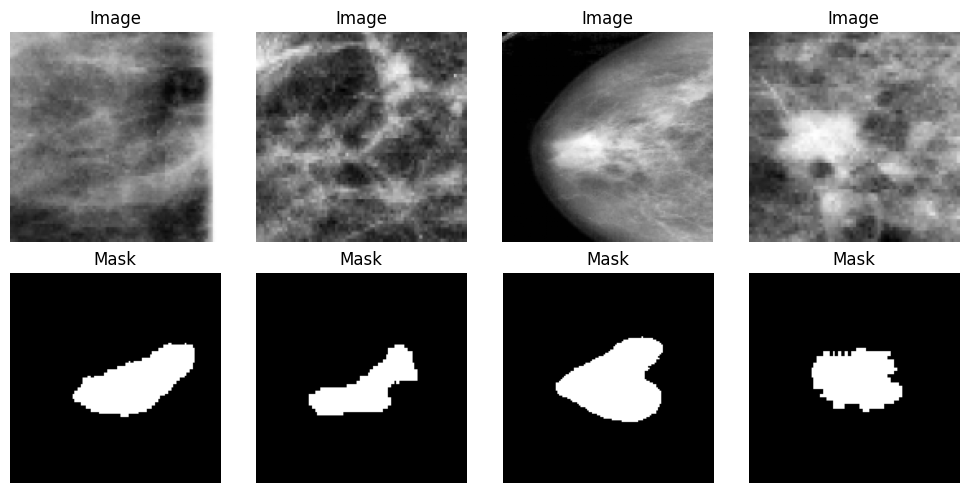

In [ ]:
plt.figure(figsize=(10,5))

for i in range(4):

    plt.subplot(2,4,i+1)
    plt.imshow(x[i].squeeze(), cmap='gray')
    plt.axis("off")
    plt.title("Image")

    plt.subplot(2,4,i+5)
    plt.imshow(y[i].squeeze(), cmap='gray')
    plt.axis("off")
    plt.title("Mask")

plt.tight_layout()
plt.show()

In [ ]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

In [ ]:
print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (2269, 128, 128, 1)
Validation : (486, 128, 128, 1)
Test : (487, 128, 128, 1)


In [ ]:
class BreastDataset(Dataset):

    def __init__(self, images, masks):

        self.images = images
        self.masks = masks

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx],
            dtype=torch.float32
        )

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        )

        image = image.permute(2,0,1)
        mask = mask.permute(2,0,1)

        return image, mask

In [ ]:
train_dataset = BreastDataset(
    X_train,
    Y_train
)

val_dataset = BreastDataset(
    X_val,
    Y_val
)

test_dataset = BreastDataset(
    X_test,
    Y_test
)

In [ ]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


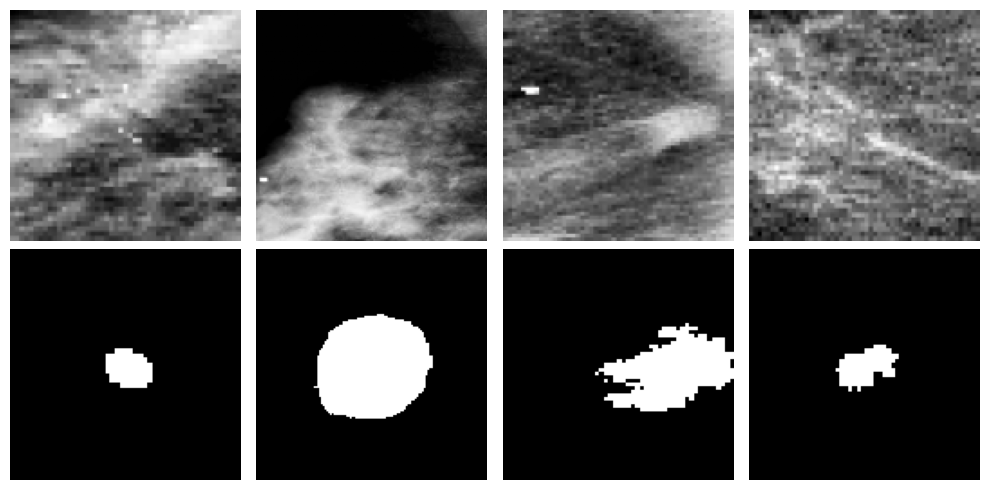

In [ ]:
plt.figure(figsize=(10,5))

for i in range(4):

    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(masks[i][0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torchvision
import torch.nn.functional as F

In [ ]:
class ResNetEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        backbone = torchvision.models.resnet34(weights=torchvision.models.ResNet34_Weights.DEFAULT)

        # Modify first conv layer for grayscale images
        backbone.conv1 = nn.Conv2d(
            1,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.initial = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.maxpool = backbone.maxpool

        self.encoder1 = backbone.layer1
        self.encoder2 = backbone.layer2
        self.encoder3 = backbone.layer3
        self.encoder4 = backbone.layer4

    def forward(self, x):

        x0 = self.initial(x)      # 64 x 64 x 64
        x1 = self.maxpool(x0)

        x1 = self.encoder1(x1)    # 64 x 32 x 32
        x2 = self.encoder2(x1)    # 128 x 16 x 16
        x3 = self.encoder3(x2)    # 256 x 8 x 8
        x4 = self.encoder4(x3)    # 512 x 4 x 4

        return x0, x1, x2, x3, x4

In [ ]:
class PatchEmbedding(nn.Module):

    def __init__(self, embed_dim=512):

        super().__init__()

        self.embed_dim = embed_dim

    def forward(self, x):

        B, C, H, W = x.shape

        x = x.flatten(2)

        x = x.transpose(1,2)

        return x

In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self,
                 num_patches=16,
                 embed_dim=512):

        super().__init__()

        self.position = nn.Parameter(
            torch.randn(1, num_patches, embed_dim)
        )

    def forward(self, x):

        return x + self.position

In [ ]:
class MultiHeadAttention(nn.Module):

    def __init__(self,
                 dim=512,
                 heads=8):

        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

    def forward(self, x):

        out, _ = self.attention(x,x,x)

        return out

In [ ]:
class FeedForward(nn.Module):

    def __init__(self,
                 dim=512,
                 hidden_dim=2048):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(dim, hidden_dim),

            nn.GELU(),

            nn.Linear(hidden_dim, dim)

        )

    def forward(self, x):

        return self.net(x)

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self,
                 dim=512,
                 heads=8):

        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = MultiHeadAttention(dim, heads)

        self.norm2 = nn.LayerNorm(dim)

        self.ffn = FeedForward(dim)

    def forward(self, x):

        x = x + self.attn(self.norm1(x))

        x = x + self.ffn(self.norm2(x))

        return x

In [ ]:
class TransformerDecoder(nn.Module):

    def __init__(self,
                 depth=4):

        super().__init__()

        self.layers = nn.ModuleList(

            [TransformerBlock() for _ in range(depth)]

        )

    def forward(self, x):

        for layer in self.layers:

            x = layer(x)

        return x

In [ ]:
class DecoderBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 skip_channels,
                 out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = nn.Sequential(

            nn.Conv2d(
                out_channels + skip_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)

        )

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)

In [ ]:
class HybridCNNTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = ResNetEncoder()

        self.patch = PatchEmbedding()

        self.position = PositionalEncoding()

        self.transformer = TransformerDecoder()

        self.decoder4 = DecoderBlock(512,256,256)

        self.decoder3 = DecoderBlock(256,128,128)

        self.decoder2 = DecoderBlock(128,64,64)

        self.decoder1 = DecoderBlock(64, 64, 32)

        # Final upsampling block (64×64 → 128×128)
        self.up_final = nn.Sequential(
             nn.ConvTranspose2d(
                32,
                16,
                kernel_size=2,
                stride=2
             ),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                16,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        self.final = nn.Conv2d(
              16,
              1,
              kernel_size=1
        )

    def forward(self,x):

        s0,s1,s2,s3,b = self.encoder(x)

        tokens = self.patch(b)

        tokens = self.position(tokens)

        tokens = self.transformer(tokens)

        B,N,C = tokens.shape

        feature = tokens.transpose(1,2)

        feature = feature.view(B,C,4,4)

        d4 = self.decoder4(feature,s3)

        d3 = self.decoder3(d4,s2)

        d2 = self.decoder2(d3,s1)

        d1 = self.decoder1(d2, s0)

        d0 = self.up_final(d1)

        out = self.final(d0)

        return out

In [ ]:
model = HybridCNNTransformer().to(device)

print(model)

HybridCNNTransformer(
  (encoder): ResNetEncoder(
    (initial): Sequential(
      (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (encoder1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d

In [ ]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)

print("Trainable Parameters :", trainable_params)

Total Parameters : 36959569
Trainable Parameters : 36959569


In [ ]:
images, masks = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(images.shape)

print(outputs.shape)

torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


In [ ]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):

        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()

        dice = (2. * intersection + self.smooth) / (
            pred.sum() + target.sum() + self.smooth
        )

        return 1 - dice

In [ ]:
class DiceBCEWithLogitsLoss(nn.Module):

    def __init__(self, smooth=1):
        super().__init__()

        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):

        bce = self.bce(pred, target)

        pred = torch.sigmoid(pred)

        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()

        dice = (2 * intersection + self.smooth) / (
            pred.sum() + target.sum() + self.smooth
        )

        dice_loss = 1 - dice

        return bce + dice_loss

In [ ]:
def calculate_metrics(pred, target):
    """
    Returns TP, FP, FN, TN for one batch.
    """

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    TP = (pred * target).sum().item()

    FP = (pred * (1 - target)).sum().item()

    FN = ((1 - pred) * target).sum().item()

    TN = ((1 - pred) * (1 - target)).sum().item()

    return TP, FP, FN, TN

In [ ]:
def compute_metrics(TP, FP, FN, TN):

    smooth = 1e-7

    dice = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)

    iou = (TP + smooth) / (TP + FP + FN + smooth)

    precision = (TP + smooth) / (TP + FP + smooth)

    recall = (TP + smooth) / (TP + FN + smooth)

    f1 = (2 * precision * recall) / (precision + recall + smooth)

    accuracy = (TP + TN) / (TP + TN + FP + FN + smooth)

    return accuracy, dice, iou, precision, recall, f1

In [ ]:
criterion = DiceBCEWithLogitsLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5
)

In [ ]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_dice": [],
    "val_dice": [],

    "train_iou": [],
    "val_iou": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": []
}

In [ ]:
epochs = 50
best_dice = 0.0
patience = 10
counter = 0
min_delta = 0.001
save_path = "/content/drive/MyDrive/HybridCNNTransformer_best.pth"
for epoch in range(epochs):

    print("=" * 70)
    print(f"Epoch {epoch+1}/{epochs}")
    print("=" * 70)

    ###################################################
    # TRAIN
    ###################################################

    model.train()

    train_loss = 0.0

    train_TP = 0
    train_FP = 0
    train_FN = 0
    train_TN = 0

    for images, masks in tqdm(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        TP, FP, FN, TN = calculate_metrics(outputs, masks)

        train_TP += TP
        train_FP += FP
        train_FN += FN
        train_TN += TN

    train_loss /= len(train_loader)

    (
        train_accuracy,
        train_dice,
        train_iou,
        train_precision,
        train_recall,
        train_f1
    ) = compute_metrics(
        train_TP,
        train_FP,
        train_FN,
        train_TN
    )

    ###################################################
    # VALIDATION
    ###################################################

    model.eval()

    val_loss = 0.0

    val_TP = 0
    val_FP = 0
    val_FN = 0
    val_TN = 0

    with torch.no_grad():

        for images, masks in tqdm(val_loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            val_loss += loss.item()

            TP, FP, FN, TN = calculate_metrics(outputs, masks)

            val_TP += TP
            val_FP += FP
            val_FN += FN
            val_TN += TN

    val_loss /= len(val_loader)

    (
        val_accuracy,
        val_dice,
        val_iou,
        val_precision,
        val_recall,
        val_f1
    ) = compute_metrics(
        val_TP,
        val_FP,
        val_FN,
        val_TN
    )

    ###################################################
    # Scheduler
    ###################################################

    scheduler.step(val_dice)

    ###################################################
    # Store History
    ###################################################

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    ###################################################
    # Print Results
    ###################################################

    print()

    print(f"Train Loss          : {train_loss:.4f}")
    print(f"Validation Loss     : {val_loss:.4f}")

    print("-" * 50)

    print(f"Train Dice          : {train_dice:.4f}")
    print(f"Validation Dice     : {val_dice:.4f}")

    print(f"Train IoU           : {train_iou:.4f}")
    print(f"Validation IoU      : {val_iou:.4f}")

    print(f"Train Precision     : {train_precision:.4f}")
    print(f"Validation Precision: {val_precision:.4f}")

    print(f"Train Recall        : {train_recall:.4f}")
    print(f"Validation Recall   : {val_recall:.4f}")

    print(f"Train F1            : {train_f1:.4f}")
    print(f"Validation F1       : {val_f1:.4f}")

    ###################################################
    # Early Stopping + Save Best Model
    ###################################################

    if val_dice > best_dice + min_delta:

        best_dice = val_dice
        counter = 0

        checkpoint = {
            'epoch': epoch + 1,
            'best_dice': best_dice,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }

        torch.save(checkpoint, save_path)

        print("\n✅ Best Model Saved!")
        print(f"Best Validation Dice : {best_dice:.4f}")

    else:

        counter += 1

        print(f"\nNo improvement in Validation Dice.")
        print(f"Early Stopping Counter : {counter}/{patience}")

    ###################################################
    # End Training if Patience Exceeded
    ###################################################

    if counter >= patience:

        print("\n🛑 Early Stopping Triggered!")
        print(f"Best Validation Dice : {best_dice:.4f}")

        break


Epoch 1/50


100%|██████████| 61/61 [00:00<00:00, 72.55it/s]



Train Loss          : 1.3565
Validation Loss     : 1.2523
--------------------------------------------------
Train Dice          : 0.4978
Validation Dice     : 0.6988
Train IoU           : 0.3314
Validation IoU      : 0.5370
Train Precision     : 0.3405
Validation Precision: 0.5657
Train Recall        : 0.9254
Validation Recall   : 0.9139
Train F1            : 0.4978
Validation F1       : 0.6988

✅ Best Model Saved!
Best Validation Dice : 0.6988
Epoch 2/50


100%|██████████| 61/61 [00:00<00:00, 66.33it/s]



Train Loss          : 1.2124
Validation Loss     : 1.2223
--------------------------------------------------
Train Dice          : 0.6828
Validation Dice     : 0.5769
Train IoU           : 0.5184
Validation IoU      : 0.4054
Train Precision     : 0.5351
Validation Precision: 0.4095
Train Recall        : 0.9432
Validation Recall   : 0.9759
Train F1            : 0.6828
Validation F1       : 0.5769

No improvement in Validation Dice.
Early Stopping Counter : 1/10
Epoch 3/50


...


Train Loss          : 0.2123
Validation Loss     : 0.3736
--------------------------------------------------
Train Dice          : 0.9106
Validation Dice     : 0.7918
Train IoU           : 0.8358
Validation IoU      : 0.6553
Train Precision     : 0.8984
Validation Precision: 0.8360
Train Recall        : 0.9230
Validation Recall   : 0.7520
Train F1            : 0.9106
Validation F1       : 0.7918

No improvement in Validation Dice.
Early Stopping Counter : 8/10
Epoch 17/50


100%|██████████| 61/61 [00:00<00:00, 67.73it/s]



Train Loss          : 0.1943
Validation Loss     : 0.3566
--------------------------------------------------
Train Dice          : 0.9140
Validation Dice     : 0.8016
Train IoU           : 0.8417
Validation IoU      : 0.6689
Train Precision     : 0.9040
Validation Precision: 0.8202
Train Recall        : 0.9243
Validation Recall   : 0.7839
Train F1            : 0.9140
Validation F1       : 0.8016

No improvement in Validation Dice.
Early Stopping Counter : 9/10
Epoch 18/50


100%|██████████| 61/61 [00:00<00:00, 67.72it/s]


Train Loss          : 0.1683
Validation Loss     : 0.3505
--------------------------------------------------
Train Dice          : 0.9253
Validation Dice     : 0.8047
Train IoU           : 0.8610
Validation IoU      : 0.6732
Train Precision     : 0.9174
Validation Precision: 0.8016
Train Recall        : 0.9333
Validation Recall   : 0.8078
Train F1            : 0.9253
Validation F1       : 0.8047

No improvement in Validation Dice.
Early Stopping Counter : 10/10

🛑 Early Stopping Triggered!
Best Validation Dice : 0.8049


In [ ]:
checkpoint = torch.load(save_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])

optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

best_epoch = checkpoint['epoch']
best_dice = checkpoint['best_dice']

print("="*60)
print("Best Model Loaded Successfully")
print("="*60)
print(f"Best Epoch : {best_epoch}")
print(f"Best Validation Dice : {best_dice:.4f}")

Best Model Loaded Successfully
Best Epoch : 8
Best Validation Dice : 0.8049


In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    "/content/drive/MyDrive/HybridCNNTransformer_history.csv",
    index=False
)

print("Training history saved successfully!")

Training history saved successfully!


In [ ]:
print("="*60)

print("Training Completed")

print("="*60)

print(f"Best Validation Dice : {best_dice:.4f}")

print(f"Total Epochs Trained : {len(history['train_loss'])}")

Training Completed
Best Validation Dice : 0.8049
Total Epochs Trained : 18


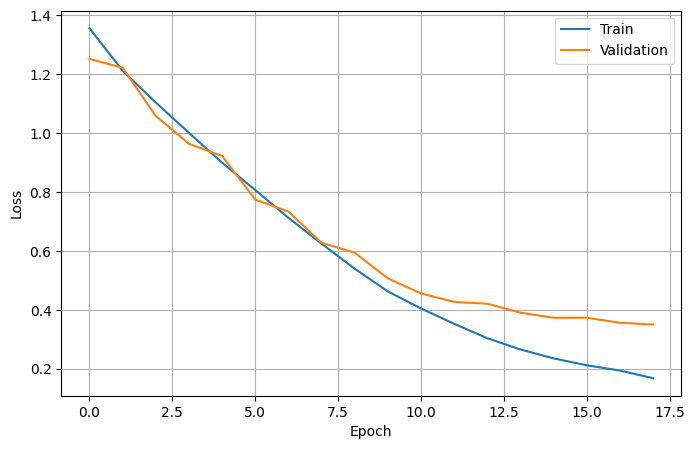

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"],label="Train")

plt.plot(history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

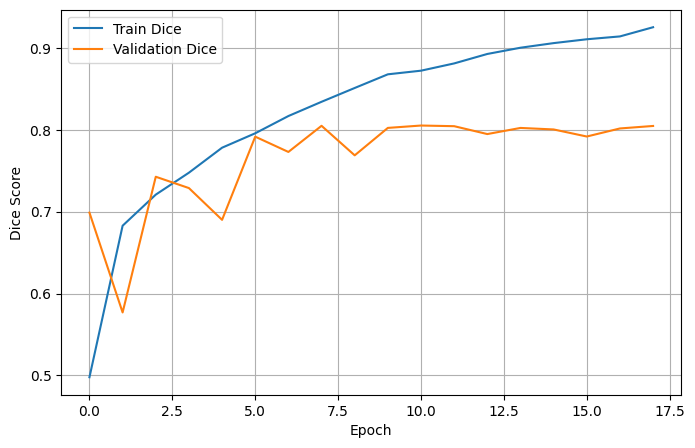

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)
plt.show()

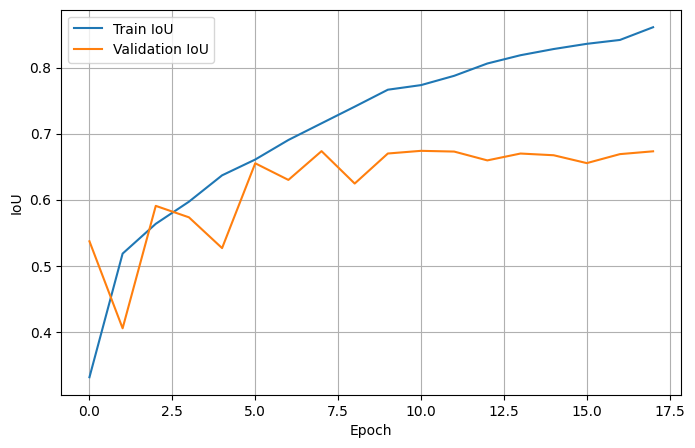

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Validation IoU")

plt.xlabel("Epoch")

plt.ylabel("IoU")

plt.legend()

plt.grid()

plt.show()

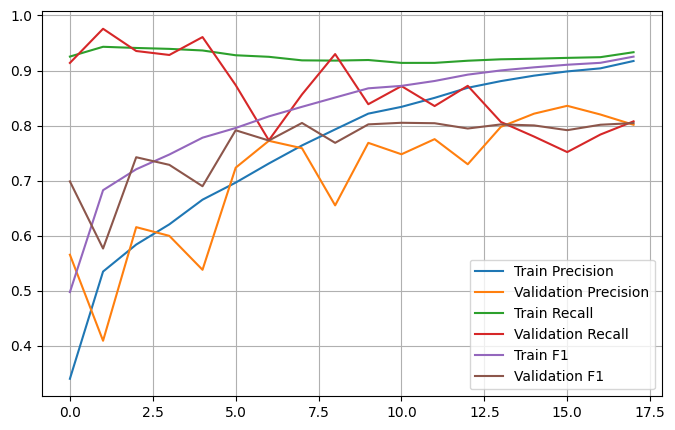

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_precision"],label="Train Precision")
plt.plot(history["val_precision"],label="Validation Precision")

plt.plot(history["train_recall"],label="Train Recall")
plt.plot(history["val_recall"],label="Validation Recall")

plt.plot(history["train_f1"],label="Train F1")
plt.plot(history["val_f1"],label="Validation F1")

plt.legend()

plt.grid()

plt.show()

In [ ]:
# Create model
model = HybridCNNTransformer().to(device)

# Load checkpoint
checkpoint = torch.load(
    "/content/drive/MyDrive/HybridCNNTransformer_best.pth",
    map_location=device
)

# Load model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Optional (only if you want to continue training)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

best_epoch = checkpoint["epoch"]
best_dice = checkpoint["best_dice"]

model.eval()

print("✅ Best model loaded successfully!")
print(f"Best Epoch : {best_epoch}")
print(f"Best Validation Dice : {best_dice:.4f}")

✅ Best model loaded successfully!
Best Epoch : 8
Best Validation Dice : 0.8049


In [ ]:
def evaluate_model(model, dataloader, criterion):

    model.eval()

    total_loss = 0.0

    total_TP = 0
    total_FP = 0
    total_FN = 0
    total_TN = 0

    with torch.no_grad():

        for images, masks in tqdm(dataloader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            total_loss += loss.item()

            TP, FP, FN, TN = calculate_metrics(outputs, masks)

            total_TP += TP
            total_FP += FP
            total_FN += FN
            total_TN += TN

    total_loss /= len(dataloader)

    accuracy, dice, iou, precision, recall, f1 = compute_metrics(
        total_TP,
        total_FP,
        total_FN,
        total_TN
    )

    print("="*50)
    print("TEST RESULTS")
    print("="*50)

    print(f"Test Loss : {total_loss:.4f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Dice      : {dice:.4f}")
    print(f"IoU       : {iou:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return total_loss, accuracy, dice, iou, precision, recall, f1

In [ ]:
test_results = evaluate_model(
    model,
    test_loader,
    criterion
)

100%|██████████| 61/61 [00:00<00:00, 66.22it/s]

TEST RESULTS
Test Loss : 0.6328
Accuracy  : 0.9665
Dice      : 0.8000
IoU       : 0.6666
Precision : 0.7622
Recall    : 0.8416
F1 Score  : 0.8000


In [ ]:
model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

outputs = torch.sigmoid(outputs)
outputs = (outputs > 0.5).float()

images = images.cpu().numpy()
masks = masks.cpu().numpy()
outputs = outputs.cpu().numpy()

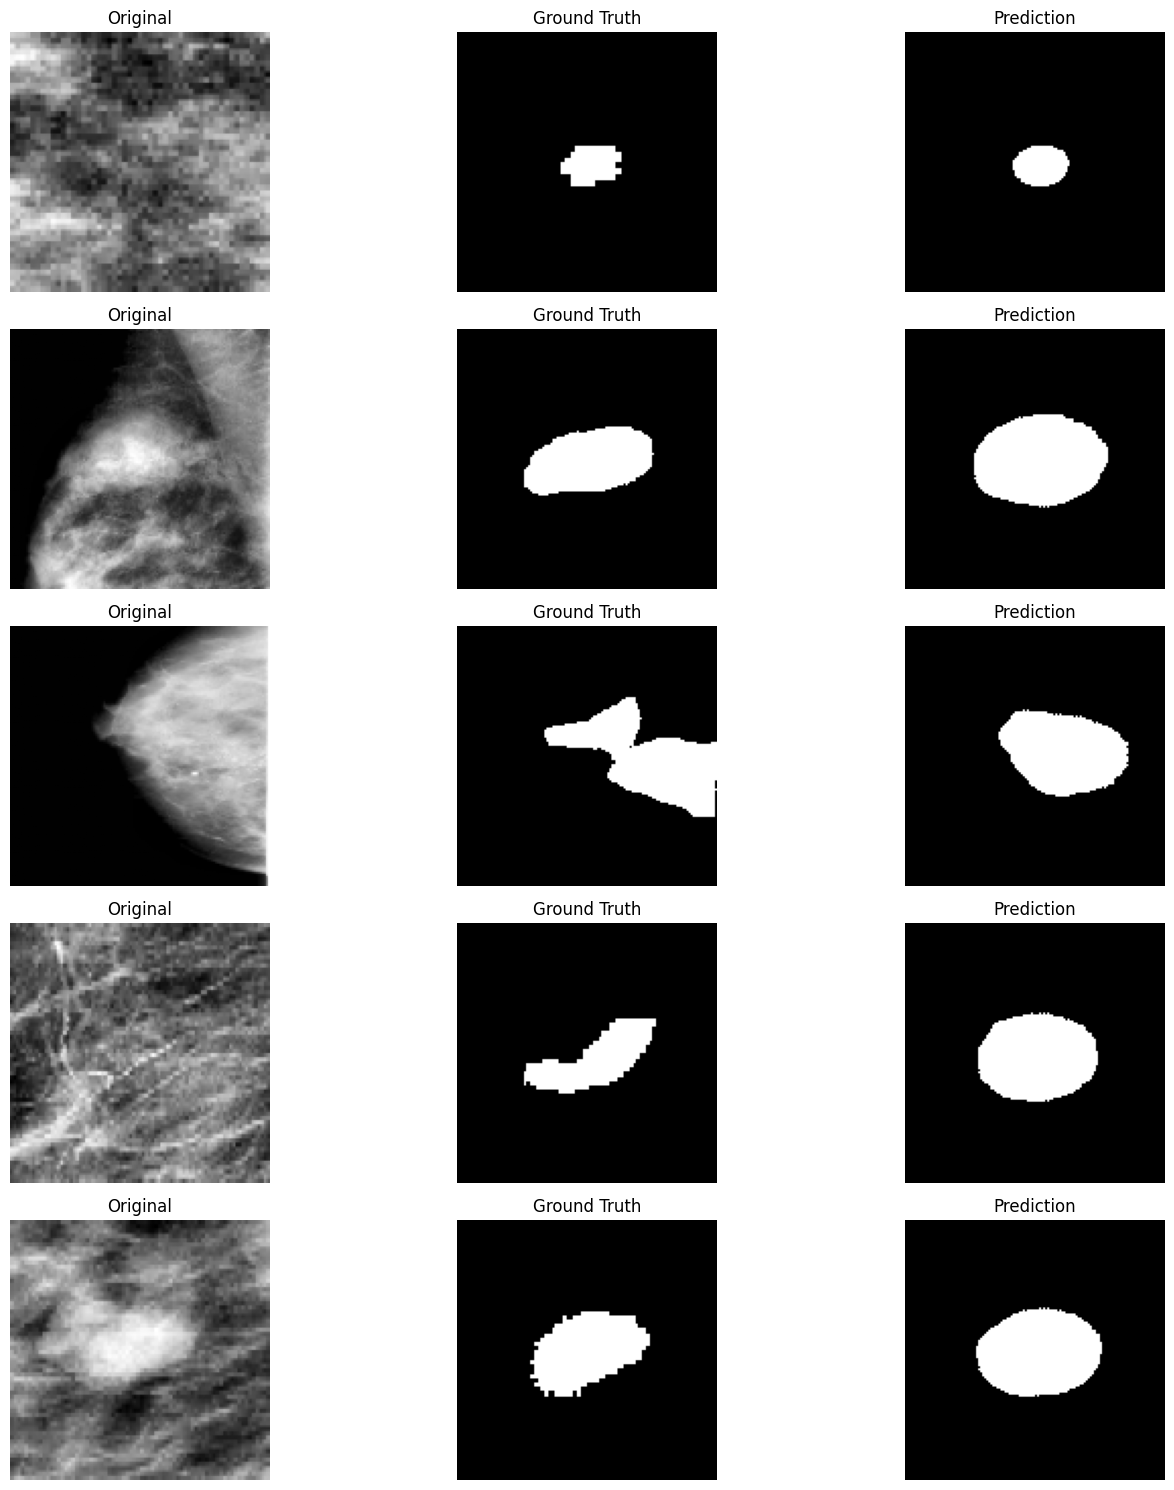

In [ ]:
num_images = 5

plt.figure(figsize=(15, num_images * 3))

for i in range(num_images):

    # Original Image
    plt.subplot(num_images, 3, 3*i + 1)

    plt.imshow(images[i][0], cmap="gray")

    plt.title("Original")

    plt.axis("off")


    # Ground Truth
    plt.subplot(num_images, 3, 3*i + 2)

    plt.imshow(masks[i][0], cmap="gray")

    plt.title("Ground Truth")

    plt.axis("off")


    # Prediction
    plt.subplot(num_images, 3, 3*i + 3)

    plt.imshow(outputs[i][0], cmap="gray")

    plt.title("Prediction")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
import os

save_dir = "/content/drive/MyDrive/Hybrid_Predictions"

os.makedirs(save_dir, exist_ok=True)

In [ ]:
count = 0

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        outputs = torch.sigmoid(outputs)
        outputs = (outputs > 0.5).float()

        images = images.cpu().numpy()
        masks = masks.numpy()
        outputs = outputs.cpu().numpy()

        for i in range(images.shape[0]):

            fig = plt.figure(figsize=(9,3))

            plt.subplot(1,3,1)
            plt.imshow(images[i][0], cmap="gray")
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.imshow(masks[i][0], cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.imshow(outputs[i][0], cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

            plt.savefig(
                os.path.join(save_dir, f"prediction_{count}.png"),
                bbox_inches="tight"
            )

            plt.close(fig)

            count += 1

            if count == 20:
                break

        if count == 20:
            break

print("20 prediction images saved successfully!")

20 prediction images saved successfully!


In [ ]:
import pandas as pd

results = pd.DataFrame({

    "Metric": [
        "Loss",
        "Accuracy",
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1"
    ],

    "Value": list(test_results)

})

results.to_csv(
    "/content/drive/MyDrive/Hybrid_Test_Metrics.csv",
    index=False
)

print(results)

      Metric     Value
0       Loss  0.632824
1   Accuracy  0.966472
2       Dice  0.799955
3        IoU  0.666604
4  Precision  0.762209
5     Recall  0.841634
6         F1  0.799955


In [ ]:
import pandas as pd

final_results = pd.DataFrame({

    "Dataset": ["Train", "Validation", "Test"],

    "Loss": [
        history["train_loss"][-1],
        history["val_loss"][-1],
        test_results[0]
    ],

    "Dice": [
        history["train_dice"][-1],
        history["val_dice"][-1],
        test_results[2]
    ],

    "IoU": [
        history["train_iou"][-1],
        history["val_iou"][-1],
        test_results[3]
    ],

    "Precision": [
        history["train_precision"][-1],
        history["val_precision"][-1],
        test_results[4]
    ],

    "Recall": [
        history["train_recall"][-1],
        history["val_recall"][-1],
        test_results[5]
    ],

    "F1 Score": [
        history["train_f1"][-1],
        history["val_f1"][-1],
        test_results[6]
    ]

})

print(final_results)

      Dataset      Loss      Dice       IoU  Precision    Recall  F1 Score
0       Train  0.168291  0.925285  0.860958   0.917384  0.933323  0.925285
1  Validation  0.350524  0.804681  0.673194   0.801578  0.807809  0.804681
2        Test  0.632824  0.799955  0.666604   0.762209  0.841634  0.799955


In [ ]:
final_results.to_csv(
    "/content/drive/MyDrive/HybridCNNTransformer_Final_Results.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!
